In [5]:
# CELL 1: SETUP & INFERENCE
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Import our locked engineering pipelines
from data_pipeline import df_train, X_train, Y_train, scaler, sensor_columns, cols_to_drop, subset, testing_data_path, rul_data_path, WINDOW_SIZE, columns
from model_cnn import train_cnn, device
from model_rf import preprocess_rf_data, train_rf_model

# Set presentation graphics standards
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 300  # High resolution for slides

print("Executing Backend Pipeline...")
# 1. Train Models
cnn_model, target_scaler = train_cnn(X_train, Y_train, epochs=15)
df_train_rf, rf_dropped_sensors = preprocess_rf_data(df_train, is_train=True)
feature_cols_rf = [
    c for c in df_train_rf.columns if c not in ['Engine_ID', 'RUL']]
rf_model = train_rf_model(
    df_train_rf[feature_cols_rf].values, df_train_rf['RUL'].values)

# 2. Load Holdout Test Set
df_test = pd.read_csv(os.path.join(
    testing_data_path, f"test_{subset}.txt"), sep=r'\s+', names=columns, index_col=False)
df_test.set_index(['Engine_ID', 'Cycle'], inplace=True)
df_test.drop(columns=cols_to_drop, inplace=True, errors='ignore')
true_rul = pd.read_csv(os.path.join(
    rul_data_path, f"RUL_{subset}.txt"), sep=r'\s+', header=None)[0].values

# 3. Generate CNN Predictions
df_test_cnn = df_test.copy()
df_test_cnn[sensor_columns] = scaler.transform(df_test_cnn[sensor_columns])
X_test_cnn_list = [df_test_cnn.xs(e, level='Engine_ID')[sensor_columns].values[-WINDOW_SIZE:, :]
                   for e in df_test.index.get_level_values('Engine_ID').unique()]
tensor_X_test = torch.tensor(
    np.array(X_test_cnn_list), dtype=torch.float32).to(device)
cnn_model.eval()
with torch.no_grad():
    cnn_predictions = target_scaler.inverse_transform(
        cnn_model(tensor_X_test).cpu().numpy()).flatten()

# 4. Generate RF Predictions
df_test_rf, _ = preprocess_rf_data(
    df_test, is_train=False, dropped_sensors=rf_dropped_sensors)
X_test_rf_list = [df_test_rf.xs(e, level='Engine_ID')[
    feature_cols_rf].iloc[-1].values for e in df_test.index.get_level_values('Engine_ID').unique()]
rf_predictions = rf_model.predict(np.array(X_test_rf_list))

print("Pipeline execution complete. Ready for visualization.")

Executing Backend Pipeline...
Active Device: mps

--- INITIATING NETWORK TRAINING (SCALED TARGETS) ---
Epoch 01/15 | Average MSE Loss: 0.0124
Epoch 02/15 | Average MSE Loss: 0.0090
Epoch 03/15 | Average MSE Loss: 0.0091
Epoch 04/15 | Average MSE Loss: 0.0069
Epoch 05/15 | Average MSE Loss: 0.0059
Epoch 06/15 | Average MSE Loss: 0.0051
Epoch 07/15 | Average MSE Loss: 0.0043
Epoch 08/15 | Average MSE Loss: 0.0037
Epoch 09/15 | Average MSE Loss: 0.0030
Epoch 10/15 | Average MSE Loss: 0.0028
Epoch 11/15 | Average MSE Loss: 0.0025
Epoch 12/15 | Average MSE Loss: 0.0021
Epoch 13/15 | Average MSE Loss: 0.0020
Epoch 14/15 | Average MSE Loss: 0.0019
Epoch 15/15 | Average MSE Loss: 0.0018
--- INITIATING RANDOM FOREST TRAINING ---
Random Forest compilation and training complete.
Pipeline execution complete. Ready for visualization.


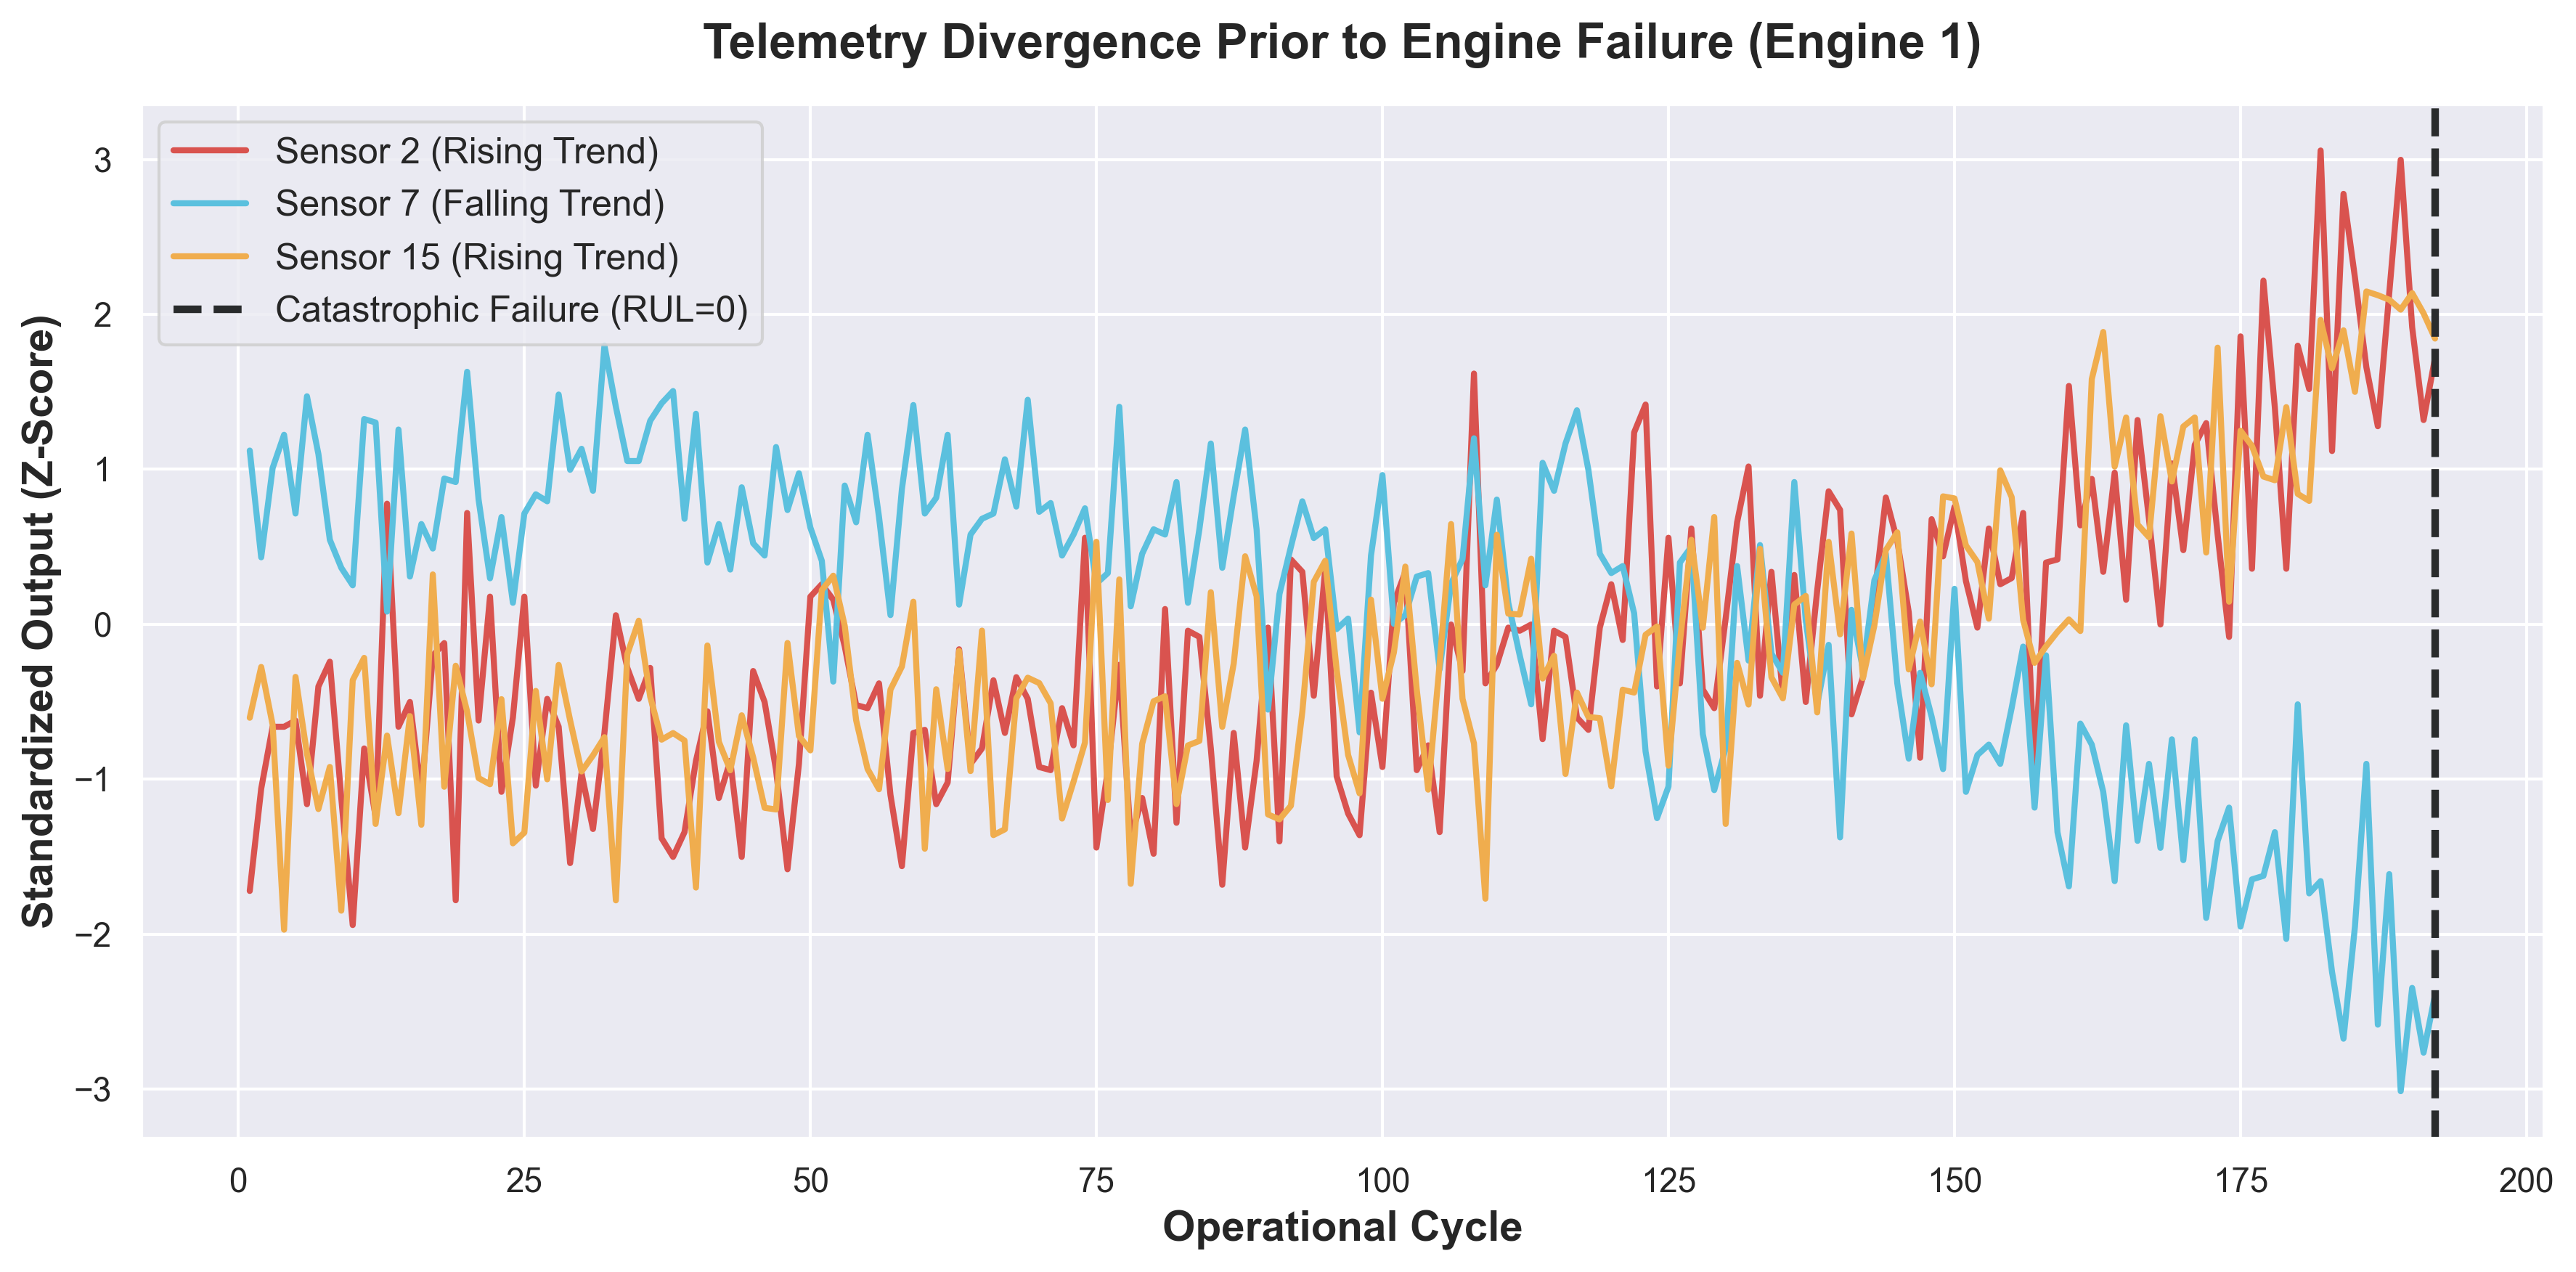

In [6]:
# CELL 2: MULTI-SENSOR DEGRADATION SIGNATURE
engine_1_scaled = df_train.xs(1, level='Engine_ID')[sensor_columns]
engine_1_eol = len(engine_1_scaled)

plt.figure(figsize=(12, 6))
# Plotting three distinct geometric narratives
plt.plot(engine_1_scaled.index, engine_1_scaled['Sensor_2'],
         label='Sensor 2 (Rising Trend)', color='#d9534f', linewidth=2)
plt.plot(engine_1_scaled.index, engine_1_scaled['Sensor_7'],
         label='Sensor 7 (Falling Trend)', color='#5bc0de', linewidth=2)
plt.plot(engine_1_scaled.index, engine_1_scaled['Sensor_15'],
         label='Sensor 15 (Rising Trend)', color='#f0ad4e', linewidth=2)

plt.axvline(x=engine_1_eol, color='#292b2c', linestyle='--',
            linewidth=2.5, label='Catastrophic Failure (RUL=0)')

plt.title("Telemetry Divergence Prior to Engine Failure (Engine 1)",
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Operational Cycle", fontsize=14, fontweight='bold')
plt.ylabel("Standardized Output (Z-Score)", fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

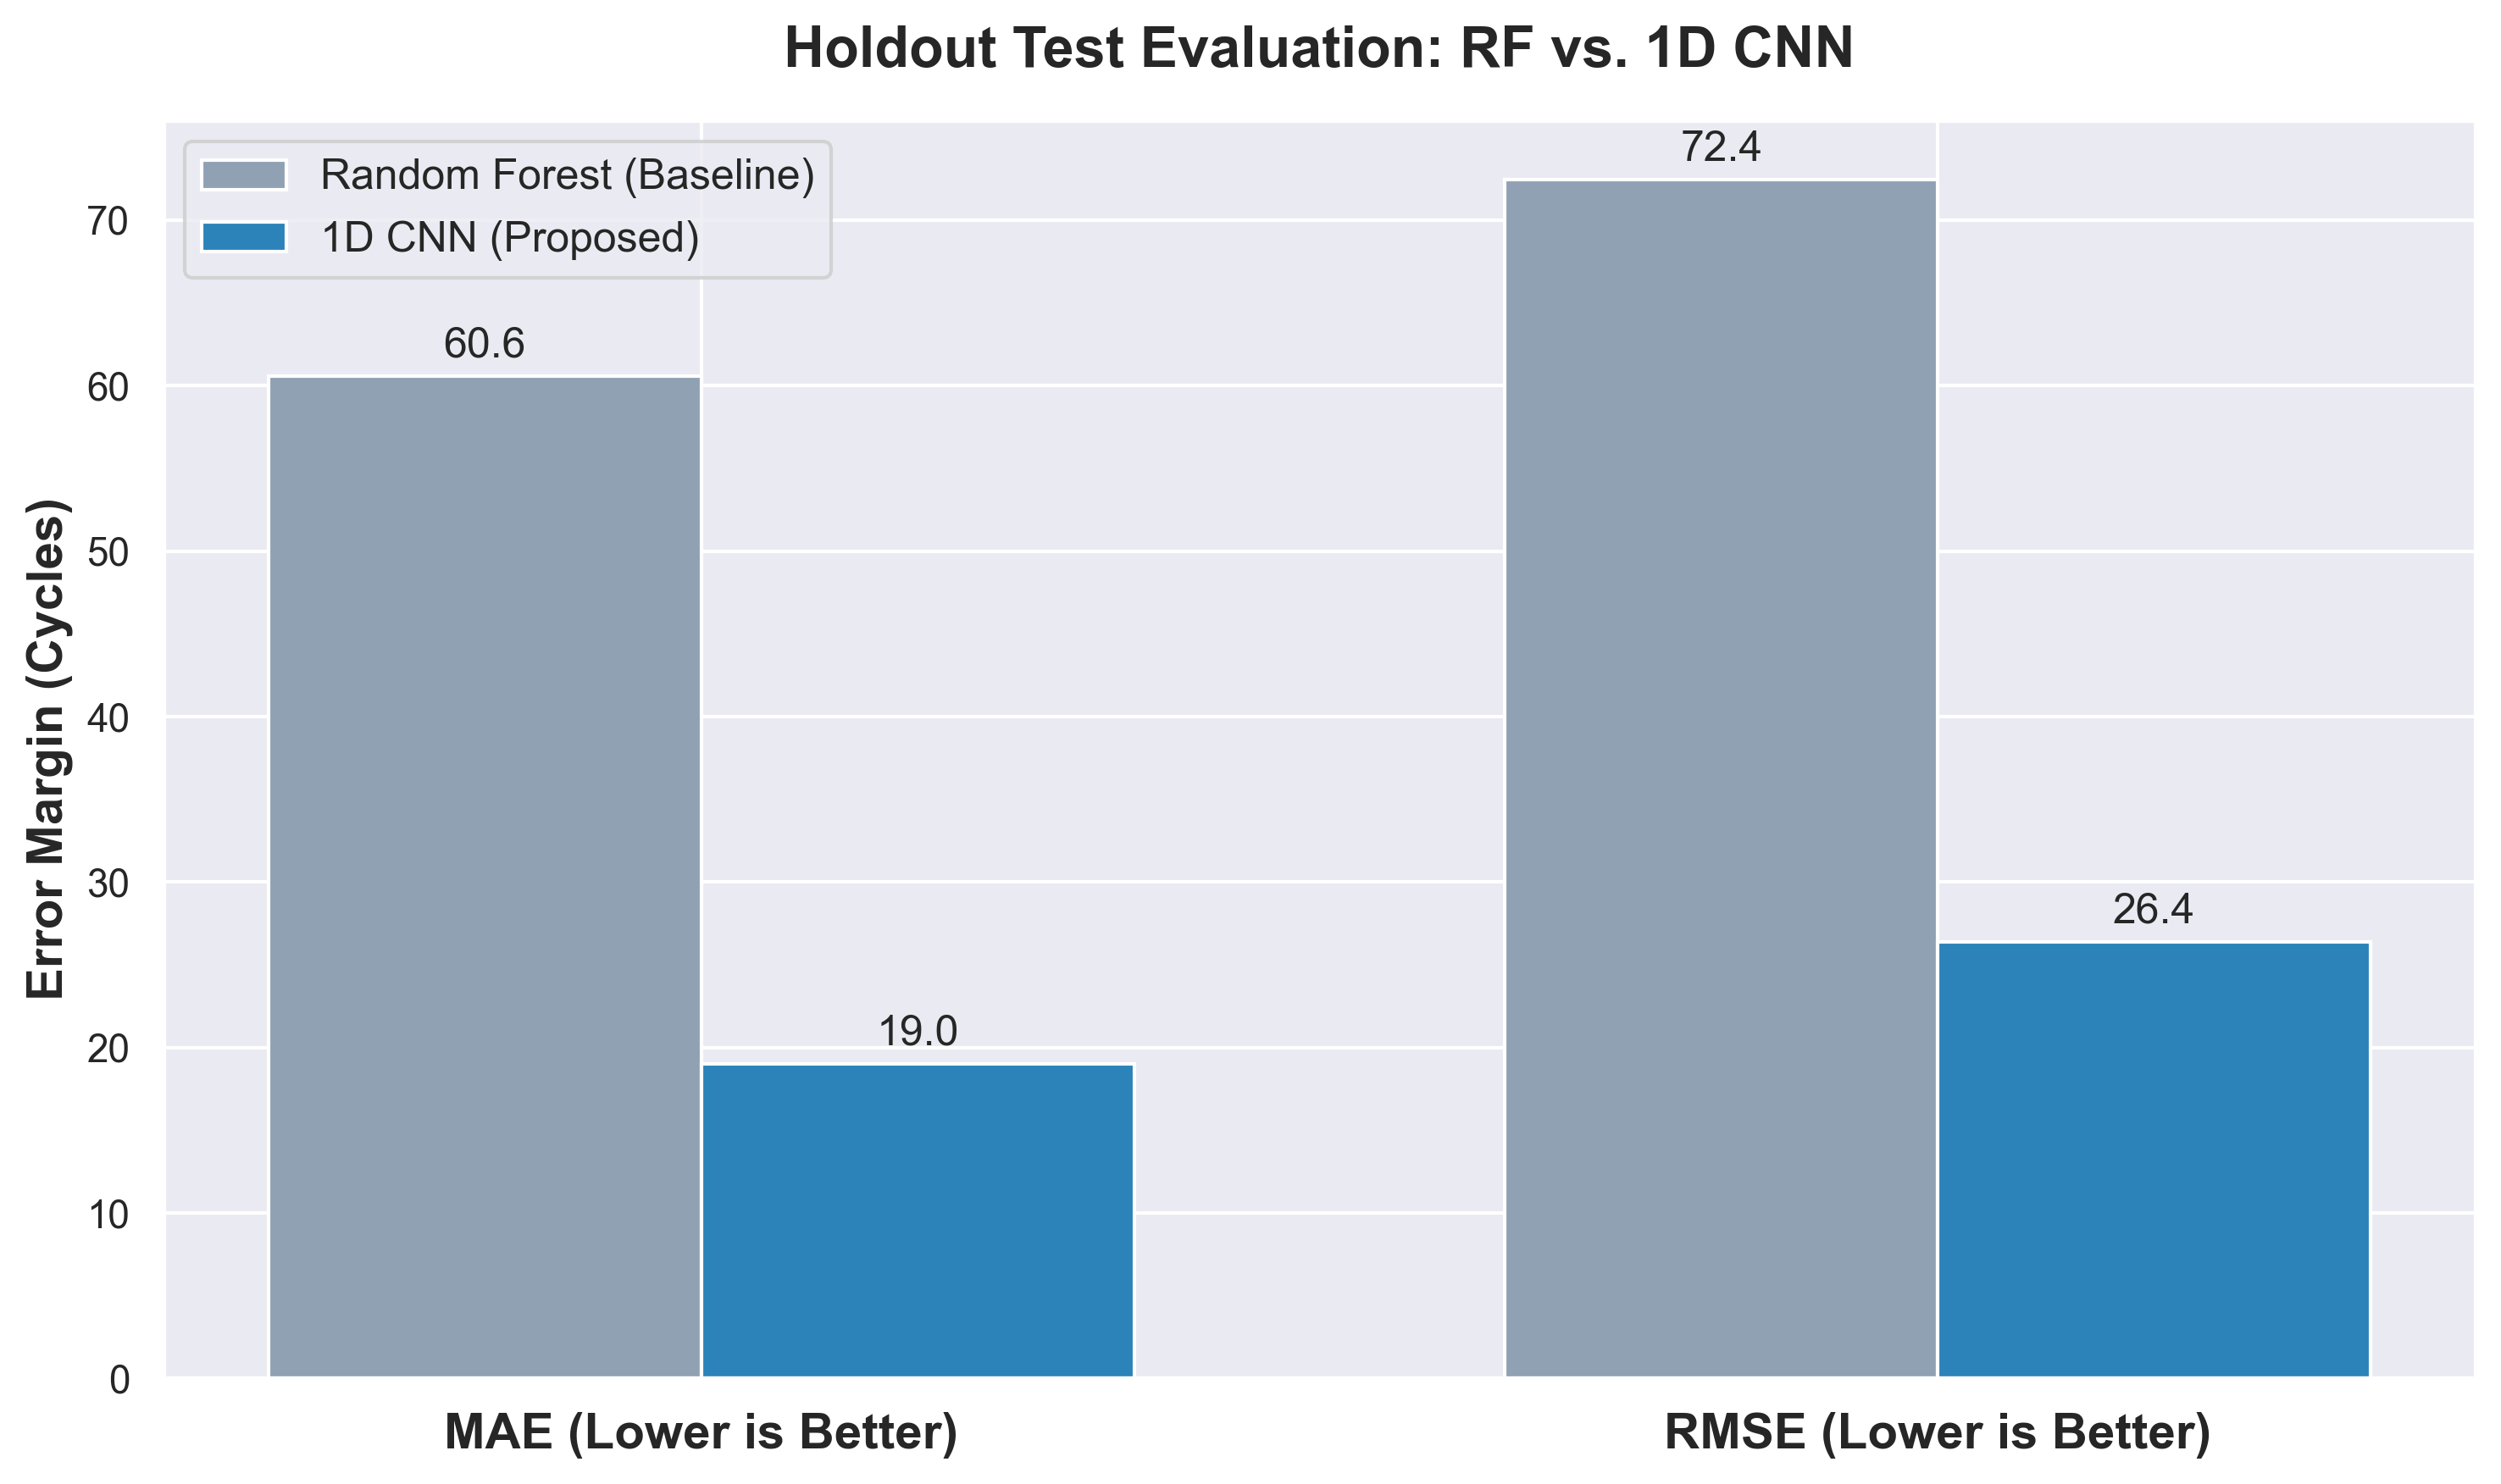

In [7]:
# CELL 3: MODEL PERFORMANCE COMPARISON
cnn_mae = mean_absolute_error(true_rul, cnn_predictions)
cnn_rmse = np.sqrt(mean_squared_error(true_rul, cnn_predictions))
rf_mae = mean_absolute_error(true_rul, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(true_rul, rf_predictions))

metrics = ['MAE (Lower is Better)', 'RMSE (Lower is Better)']
cnn_scores = [cnn_mae, cnn_rmse]
rf_scores = [rf_mae, rf_rmse]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, rf_scores, width,
                label='Random Forest (Baseline)', color='#8fa1b3')
rects2 = ax.bar(x + width/2, cnn_scores, width,
                label='1D CNN (Proposed)', color='#2b83ba')

ax.set_ylabel('Error Margin (Cycles)', fontsize=14, fontweight='bold')
ax.set_title('Holdout Test Evaluation: RF vs. 1D CNN',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=14, fontweight='bold')
ax.legend(fontsize=12)

# Auto-label the bars
ax.bar_label(rects1, fmt='%.1f', padding=3, fontsize=12)
ax.bar_label(rects2, fmt='%.1f', padding=3, fontsize=12)

plt.tight_layout()
plt.show()

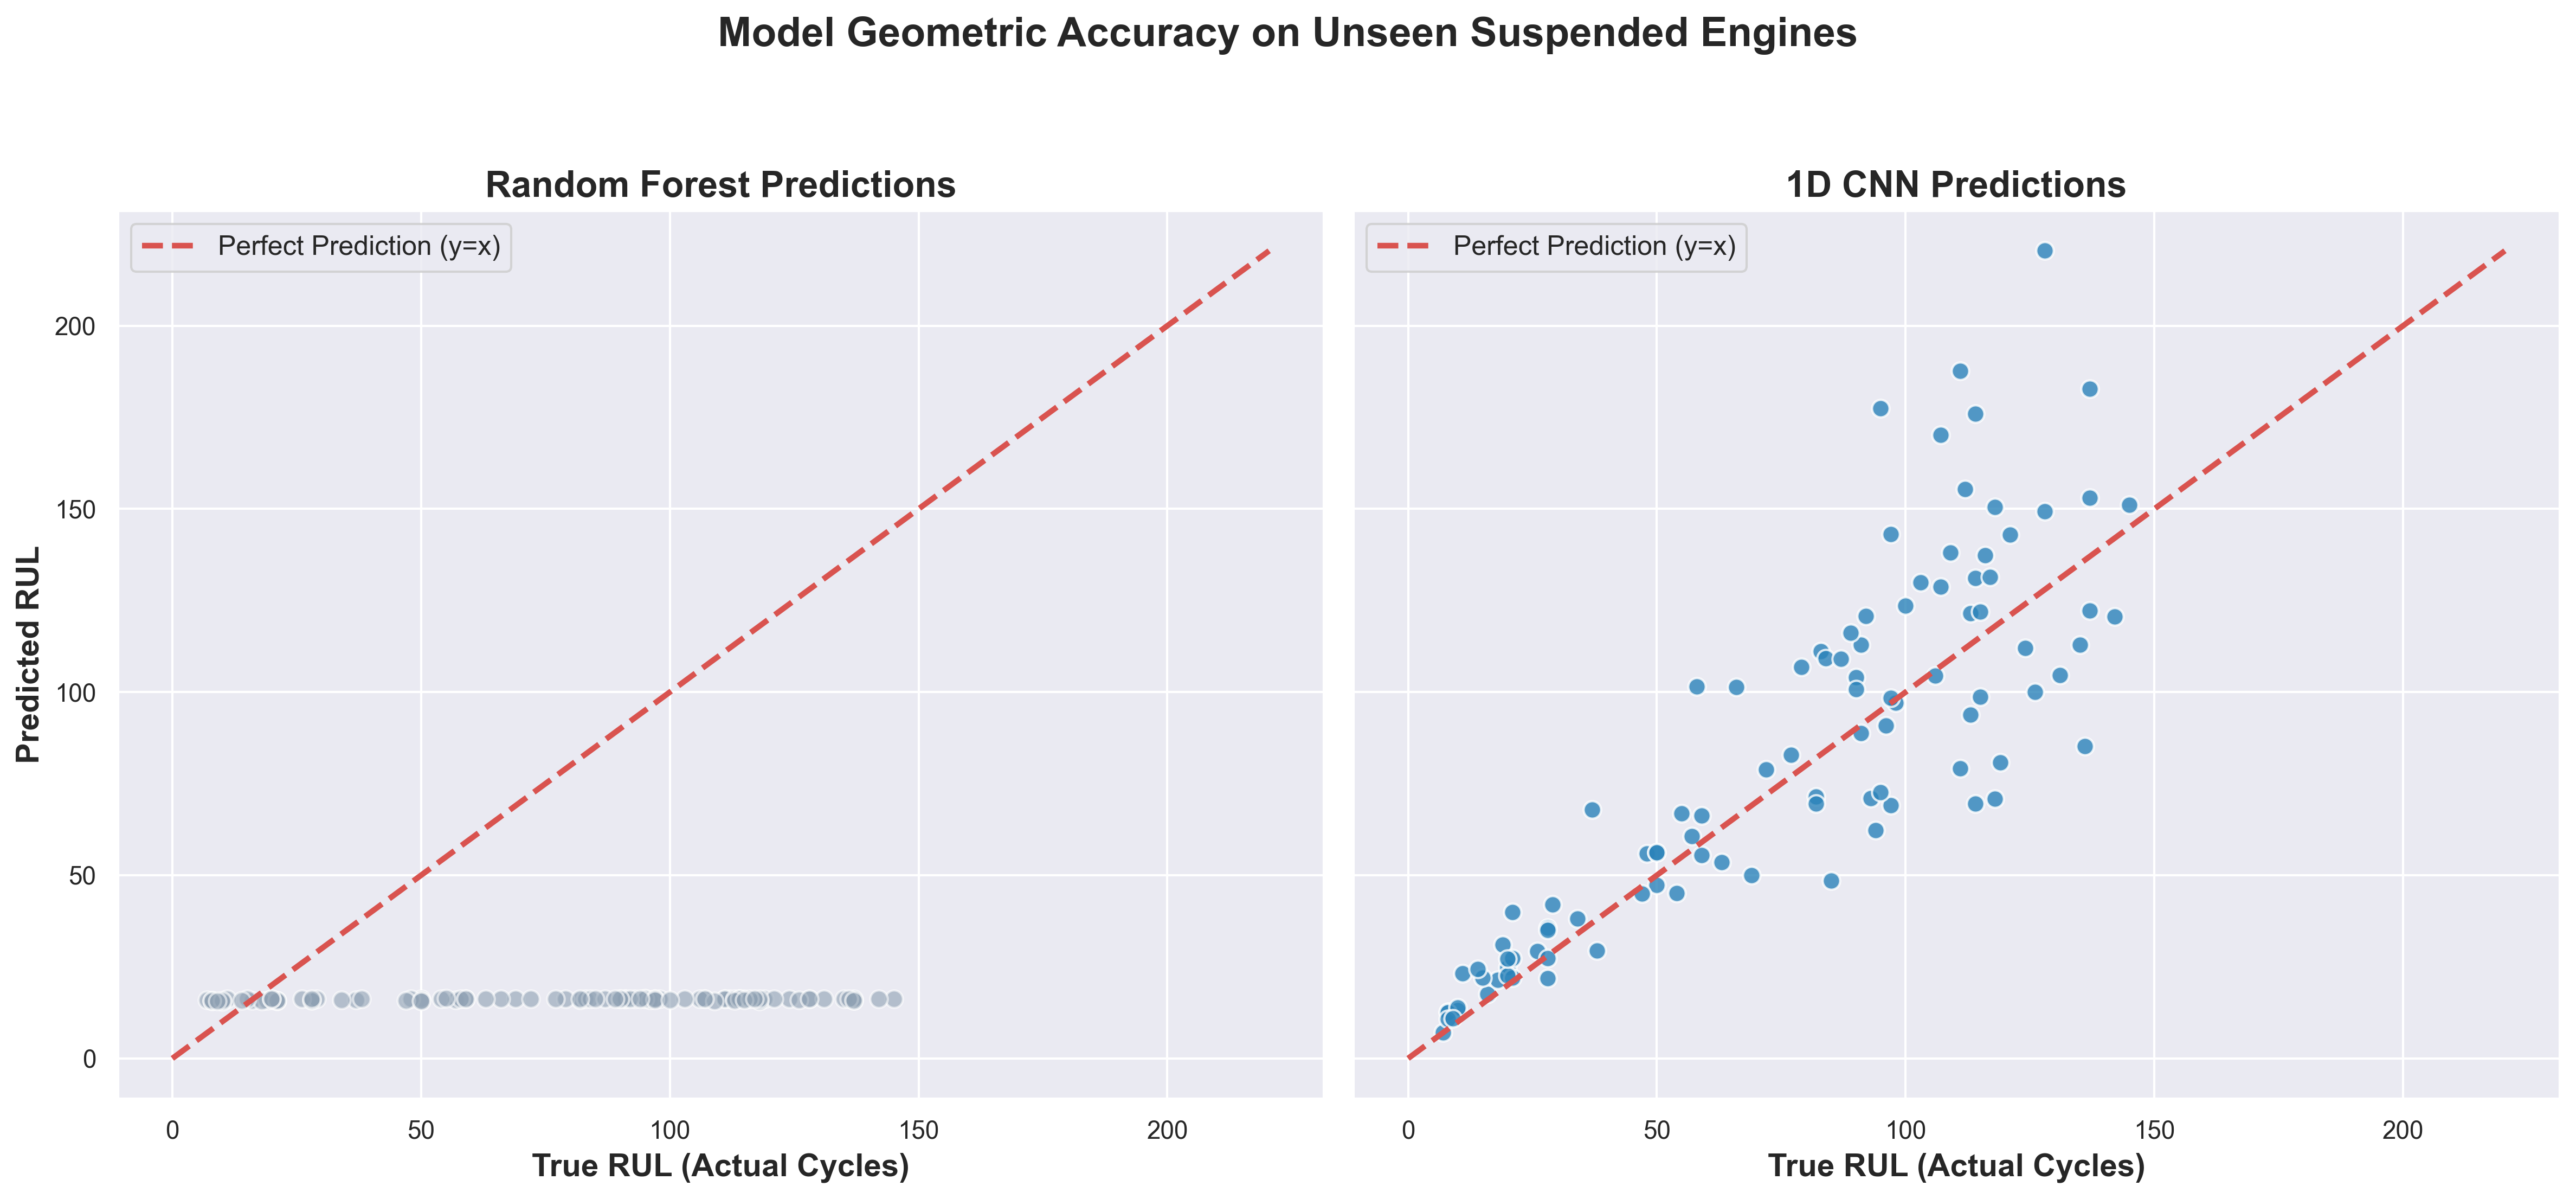

In [8]:
# CELL 4: TRUE VS. PREDICTED SCATTER
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
max_val = max(max(true_rul), max(rf_predictions), max(cnn_predictions))

# Random Forest Plot
ax1.scatter(true_rul, rf_predictions, alpha=0.6,
            color='#8fa1b3', s=60, edgecolors='white')
ax1.plot([0, max_val], [0, max_val], color='#d9534f', linestyle='--',
         linewidth=2.5, label='Perfect Prediction (y=x)')
ax1.set_title('Random Forest Predictions', fontsize=16, fontweight='bold')
ax1.set_xlabel('True RUL (Actual Cycles)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Predicted RUL', fontsize=14, fontweight='bold')
ax1.legend(fontsize=12)

# 1D CNN Plot
ax2.scatter(true_rul, cnn_predictions, alpha=0.8,
            color='#2b83ba', s=60, edgecolors='white')
ax2.plot([0, max_val], [0, max_val], color='#d9534f', linestyle='--',
         linewidth=2.5, label='Perfect Prediction (y=x)')
ax2.set_title('1D CNN Predictions', fontsize=16, fontweight='bold')
ax2.set_xlabel('True RUL (Actual Cycles)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=12)

plt.suptitle("Model Geometric Accuracy on Unseen Suspended Engines",
             fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

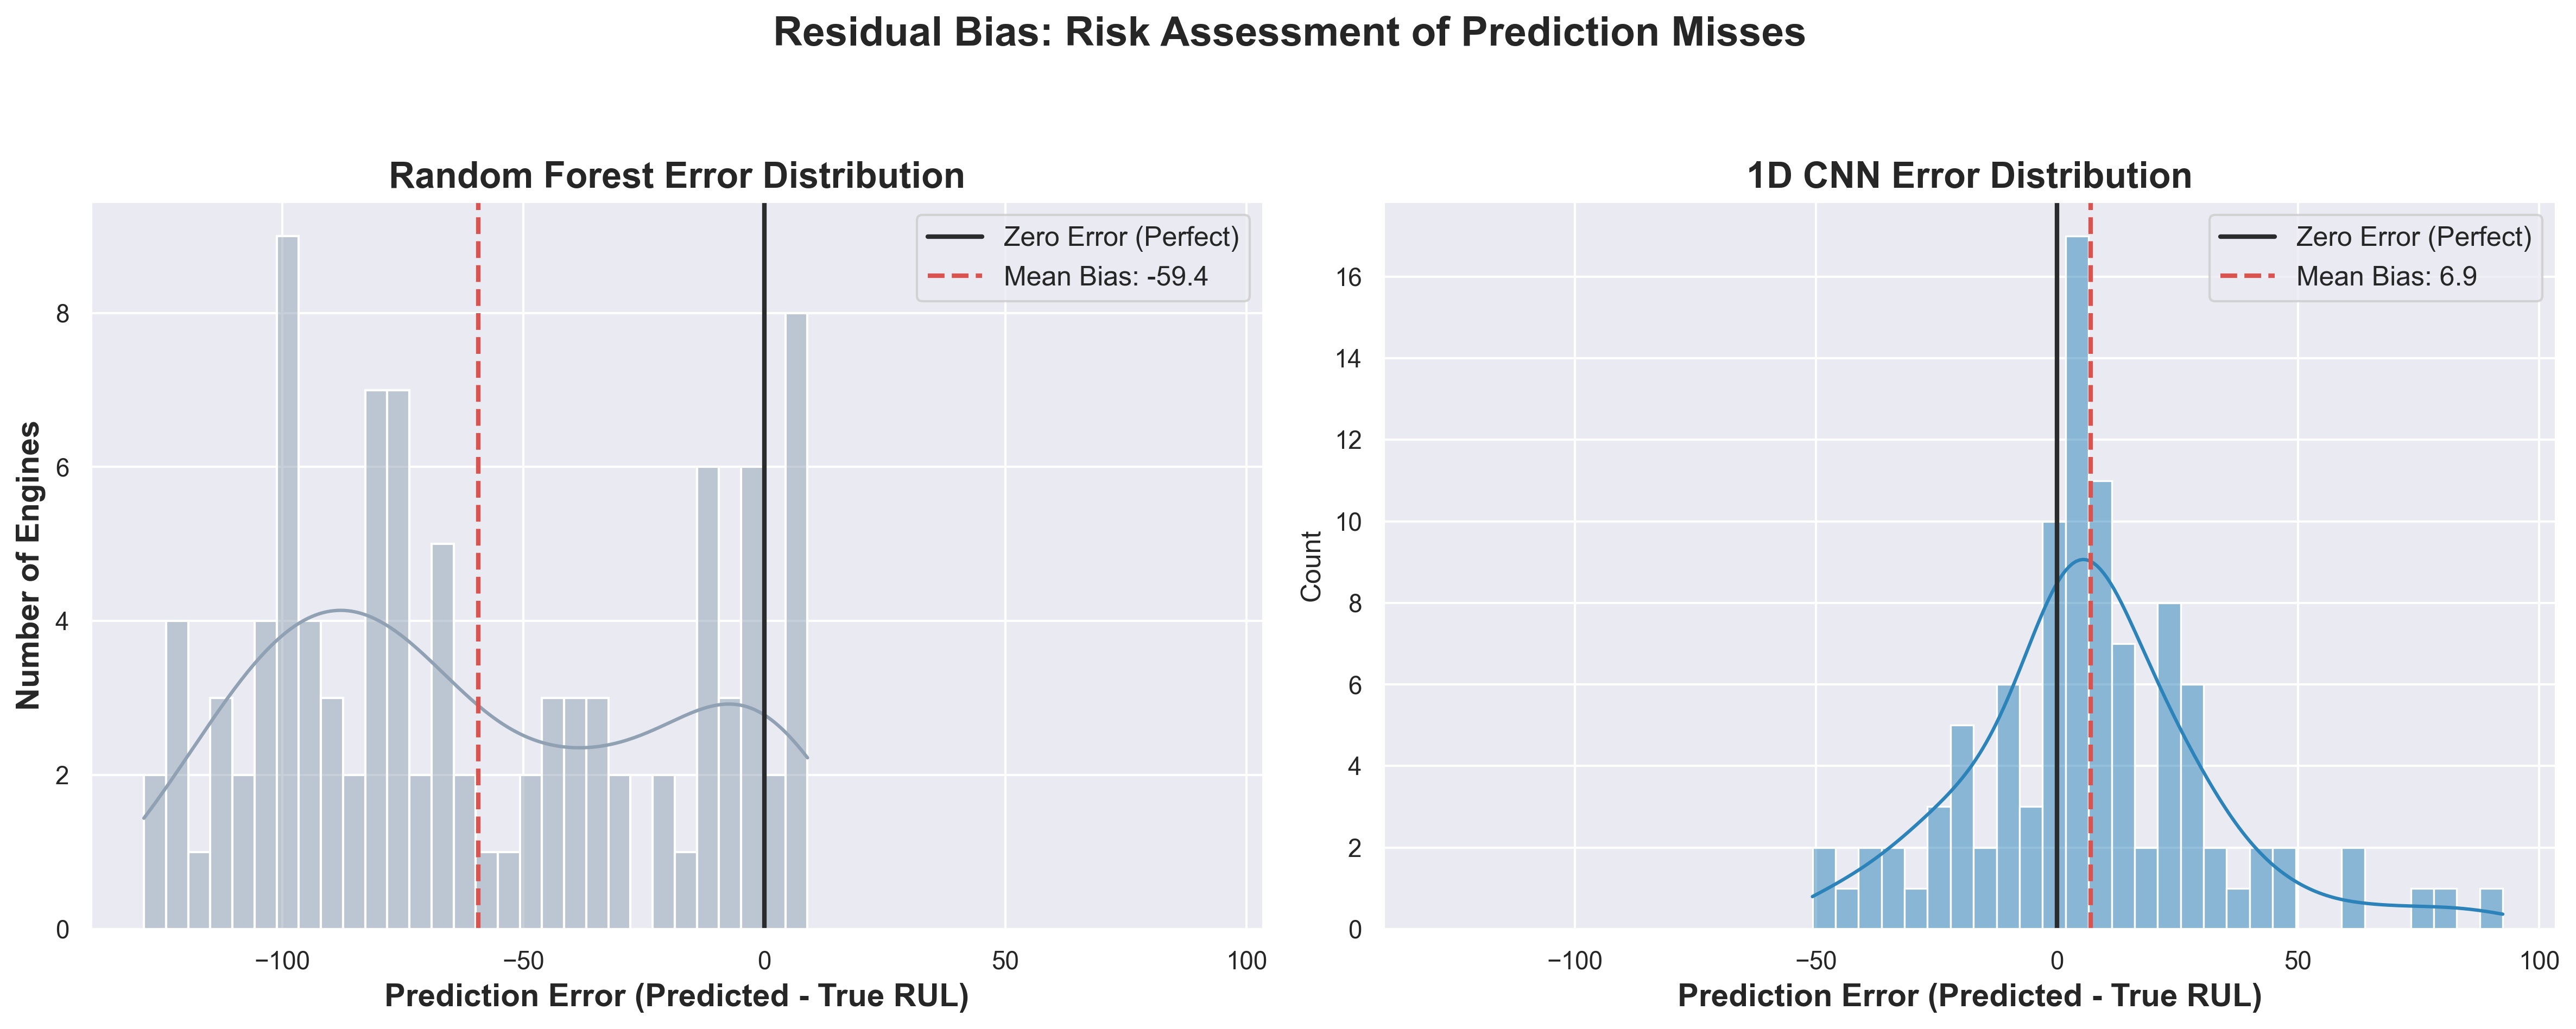

In [9]:
# CELL 5: ERROR DISTRIBUTION (BIAS ANALYSIS)
cnn_errors = cnn_predictions - true_rul
rf_errors = rf_predictions - true_rul

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Random Forest Residuals
sns.histplot(rf_errors, bins=30, kde=True,
             color='#8fa1b3', ax=ax1, edgecolor='white')
ax1.axvline(0, color='#292b2c', linestyle='-',
            linewidth=2, label='Zero Error (Perfect)')
ax1.axvline(rf_errors.mean(), color='#d9534f', linestyle='--',
            linewidth=2, label=f'Mean Bias: {rf_errors.mean():.1f}')
ax1.set_title('Random Forest Error Distribution',
              fontsize=16, fontweight='bold')
ax1.set_xlabel('Prediction Error (Predicted - True RUL)',
               fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Engines', fontsize=14, fontweight='bold')
ax1.legend(fontsize=12)

# CNN Residuals
sns.histplot(cnn_errors, bins=30, kde=True,
             color='#2b83ba', ax=ax2, edgecolor='white')
ax2.axvline(0, color='#292b2c', linestyle='-',
            linewidth=2, label='Zero Error (Perfect)')
ax2.axvline(cnn_errors.mean(), color='#d9534f', linestyle='--',
            linewidth=2, label=f'Mean Bias: {cnn_errors.mean():.1f}')
ax2.set_title('1D CNN Error Distribution', fontsize=16, fontweight='bold')
ax2.set_xlabel('Prediction Error (Predicted - True RUL)',
               fontsize=14, fontweight='bold')
ax2.legend(fontsize=12)

plt.suptitle("Residual Bias: Risk Assessment of Prediction Misses",
             fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

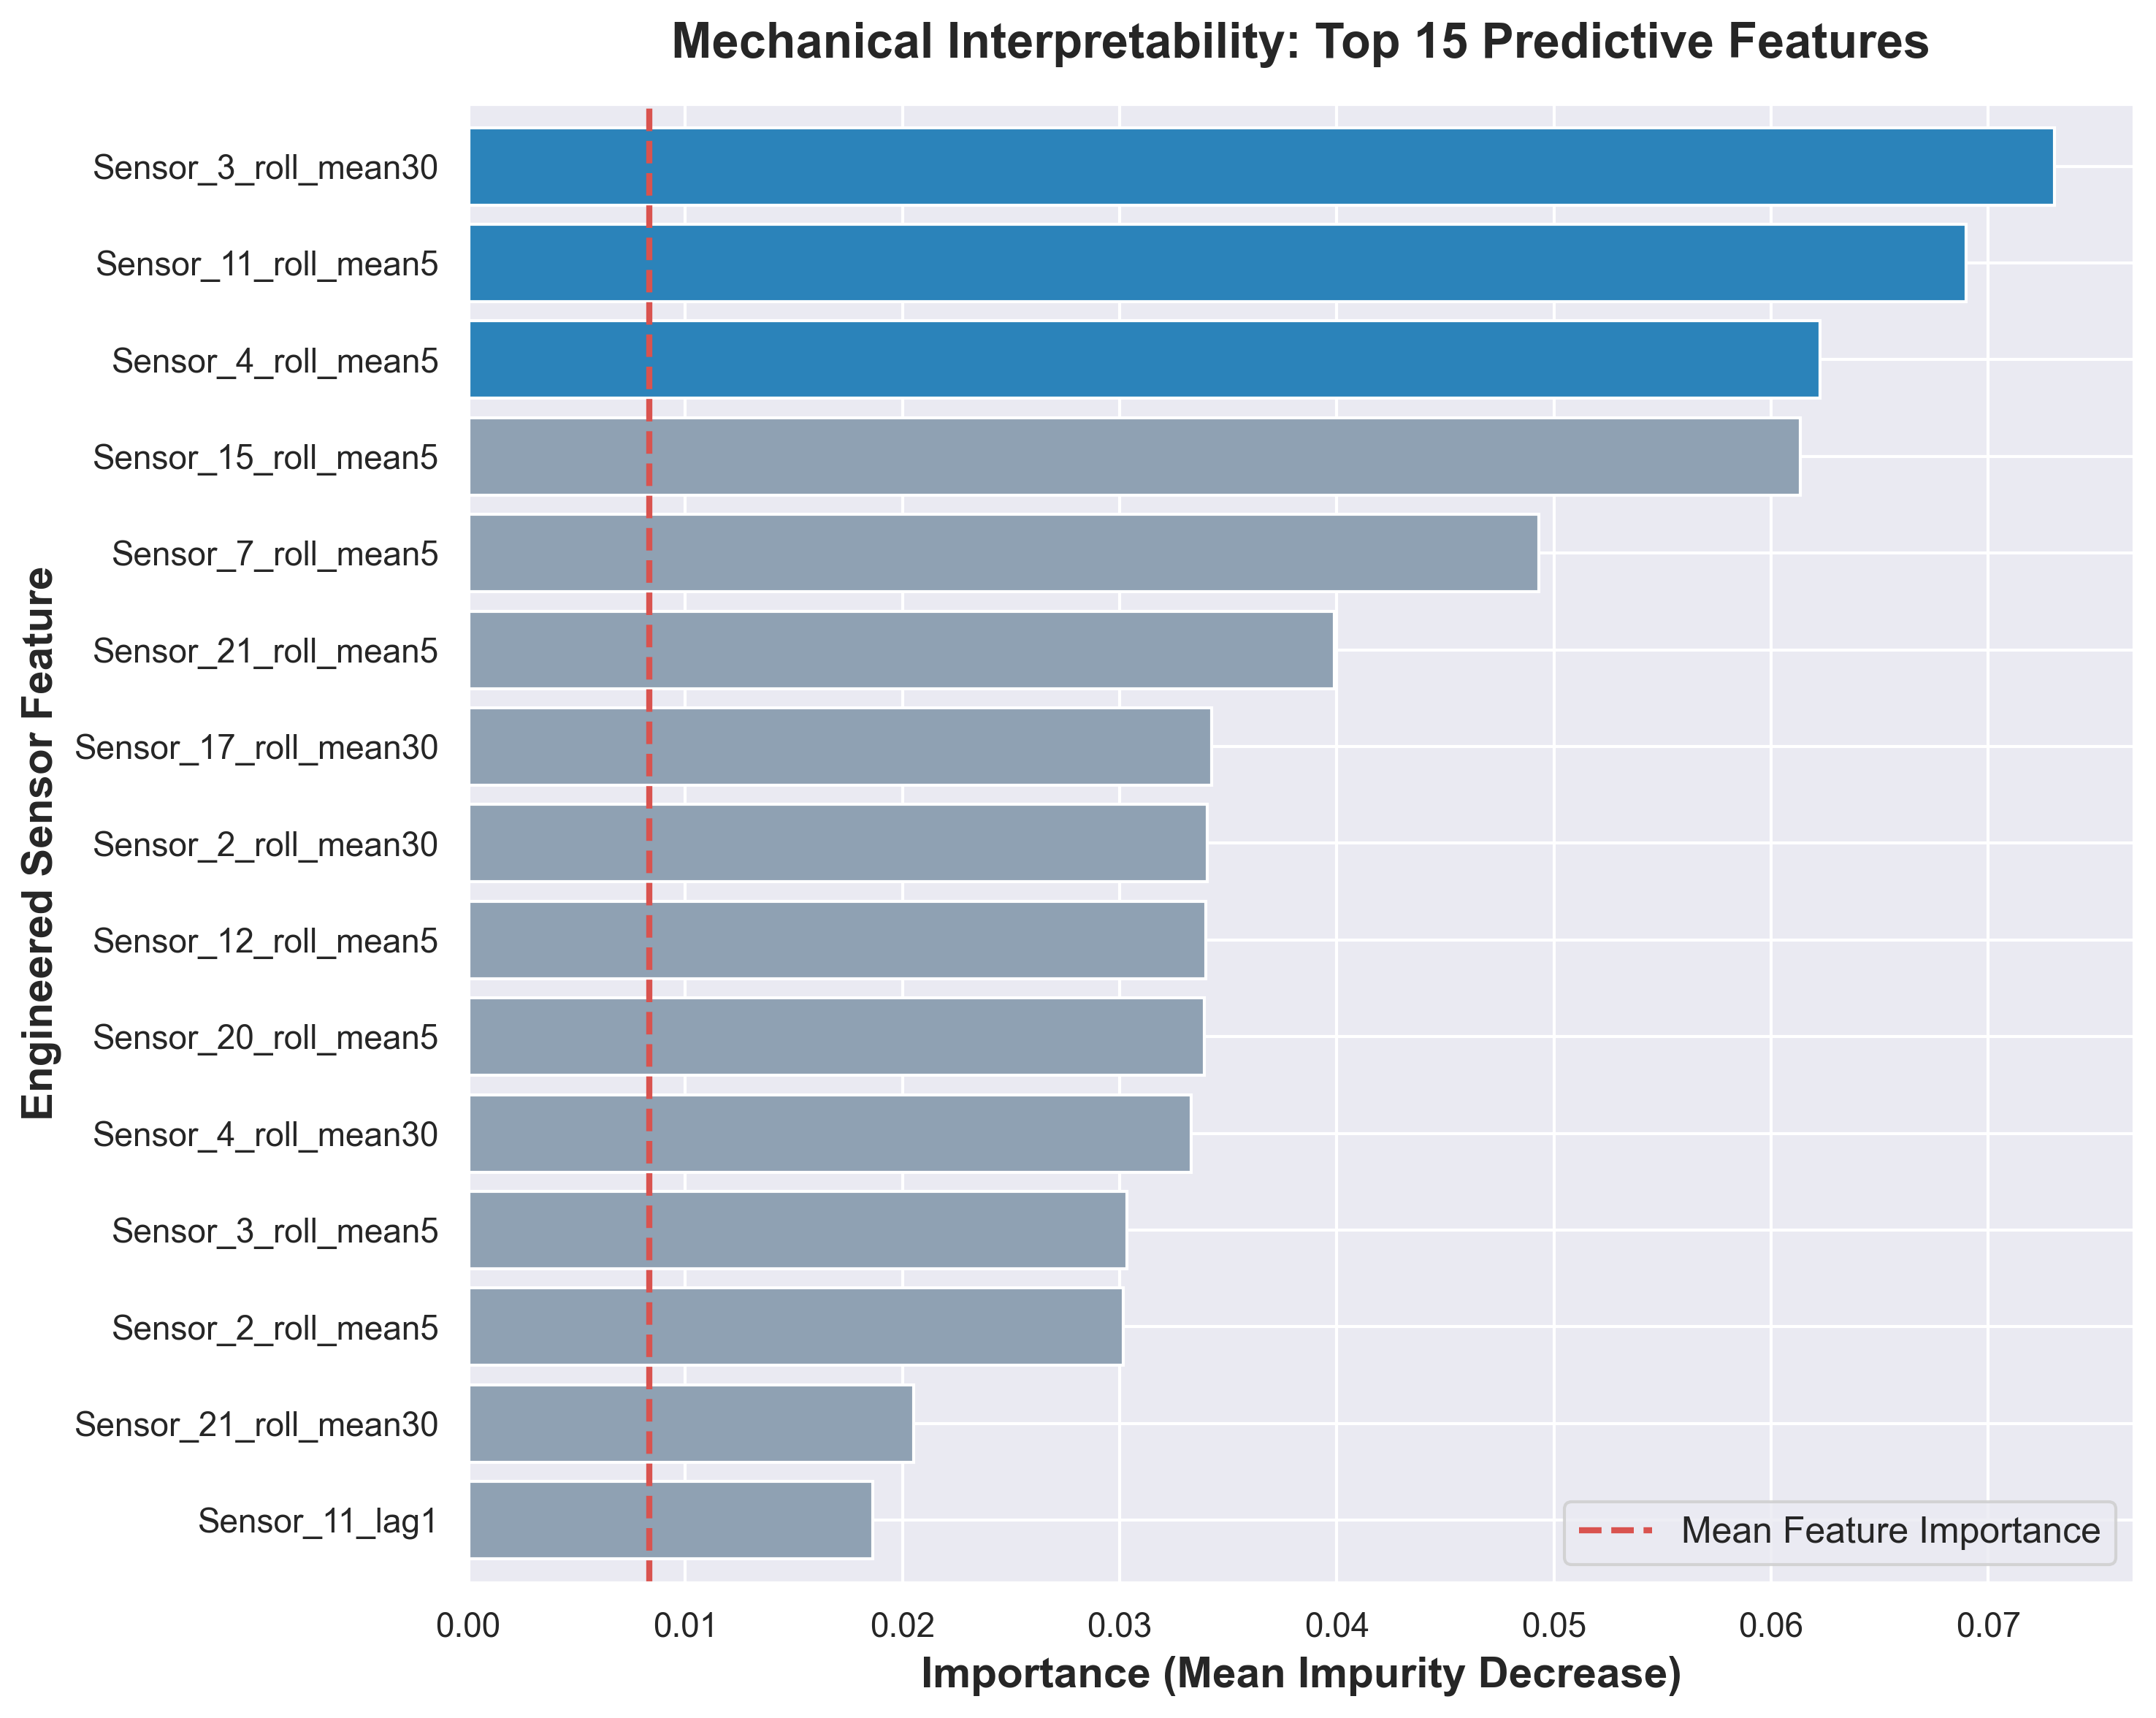

In [10]:
# CELL 6: PHYSICAL INTERPRETABILITY (FEATURE IMPORTANCE)
# Extract the top 15 features the RF used to make its decisions
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=feature_cols_rf).sort_values(ascending=False)
top_features = feat_imp.head(15).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
# Highlight the top 3 features in a distinct color to draw the eye
colors = ['#2b83ba' if i >= len(
    top_features) - 3 else '#8fa1b3' for i in range(len(top_features))]

top_features.plot(kind='barh', color=colors, width=0.8)
plt.axvline(feat_imp.mean(), color='#d9534f', linestyle='--',
            linewidth=2, label='Mean Feature Importance')

plt.title('Mechanical Interpretability: Top 15 Predictive Features',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Importance (Mean Impurity Decrease)',
           fontsize=14, fontweight='bold')
plt.ylabel('Engineered Sensor Feature', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='lower right')
plt.tight_layout()
plt.show()